# Phase 2: Demand Uncertainty Modeling

This notebook analyzes demand uncertainty by constructing forecast ratios and residuals from historical data. It performs bias checks, caps extreme outliers, fits parametric distributions (Gamma and Shifted Gamma), and compares them with nonparametric methods (Empirical Bootstrap and Gaussian KDE) using inventory-relevant upper-tail goodness-of-fit diagnostics.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))

from src.config import Config
from src.data_loader import load_train_data, filter_families
from src.demand_uncertainty import calculate_ratios, calculate_residuals, check_ratio_bias, check_residual_bias, cap_by_percentile
from src.distributions import fit_gamma_moments, fit_shifted_gamma, bootstrap_sample, kde_sample, calculate_tail_error, calculate_rmse, run_kolmogorov_smirnov, run_anderson_darling

## 1. Load Data

In [2]:
config = Config('../configs/inventory_config.yaml')
train_df = load_train_data('../../Demand Forecasting System/data/actual_fitted_sales_on_train_final.csv', config)
train_df = filter_families(train_df, config.selected_families, config)

## 2. Calculate Ratios and Residuals

In [3]:
col_family = config.columns['family']
col_actual = config.columns['train_actual']
col_fitted = config.columns['train_fitted']

results_uncertainty = {}

for family in config.selected_families:
    fam_df = train_df[train_df[col_family] == family]
    actual = fam_df[col_actual].values
    fitted = fam_df[col_fitted].values
    
    ratios = calculate_ratios(actual, fitted, config.epsilon)
    residuals = calculate_residuals(actual, fitted)
    
    results_uncertainty[family] = {
        'actual': actual,
        'ratios': ratios,
        'residuals': residuals
    }
    
    # Print bias diagnostics
    ratio_bias = check_ratio_bias(ratios)
    res_bias = check_residual_bias(residuals, mean_demand=np.mean(actual))
    
    print(f"=== Family: {family} ===")
    print(f"  Mean Ratio: {ratio_bias['mean_ratio']:.4f} (passed check: {ratio_bias['passed_bias_check']})")
    print(f"  Mean Residual: {res_bias['mean_residual']:.4f} (passed check: {res_bias['passed_bias_check']})")

=== Family: GROCERY I ===
  Mean Ratio: 1.0062 (passed check: True)
  Mean Residual: 8575.1542 (passed check: True)
=== Family: BEVERAGES ===
  Mean Ratio: 1.0095 (passed check: True)
  Mean Residual: 9310.1274 (passed check: True)
=== Family: CLEANING ===
  Mean Ratio: 0.9971 (passed check: True)
  Mean Residual: -969.0208 (passed check: True)


## 3. Cap Extreme Values (Winsorization)

In [4]:
for family in config.selected_families:
    ratios = results_uncertainty[family]['ratios']
    # Center ratios to have mean 1.0
    ratios_centered = ratios / np.mean(ratios)
    ratios_capped = cap_by_percentile(ratios_centered, 1.0, 99.0)
    
    results_uncertainty[family]['ratios_centered'] = ratios_centered
    results_uncertainty[family]['ratios_capped'] = ratios_capped
    print(f"{family} ratios capped. Min: {ratios_capped.min():.4f}, Max: {ratios_capped.max():.4f}")

GROCERY I ratios capped. Min: 0.8244, Max: 1.4894
BEVERAGES ratios capped. Min: 0.6072, Max: 1.7606
CLEANING ratios capped. Min: 0.8317, Max: 1.3399


## 4. Distribution Fit Diagnostics & Diagnostics Table


Goodness-of-Fit Summary - GROCERY I
  Standard Gamma RMSE: 0.0301
  Shifted Gamma RMSE:  0.0203
  Gaussian KDE RMSE:   0.0082


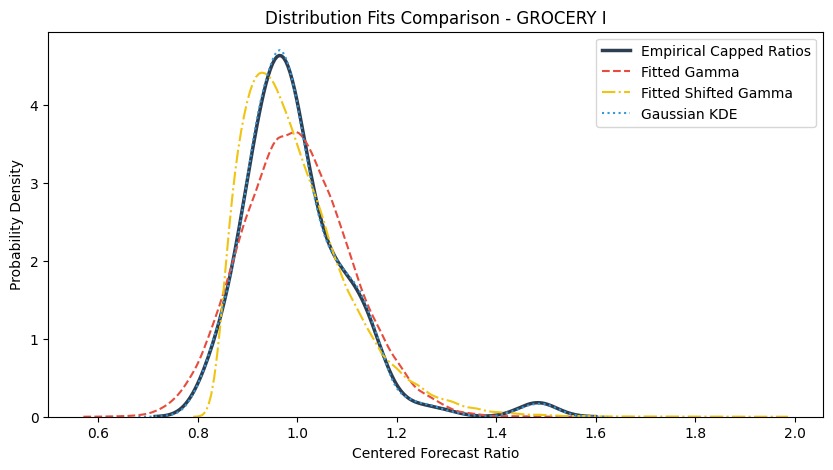


Goodness-of-Fit Summary - BEVERAGES
  Standard Gamma RMSE: 0.0479
  Shifted Gamma RMSE:  0.0422
  Gaussian KDE RMSE:   0.0145


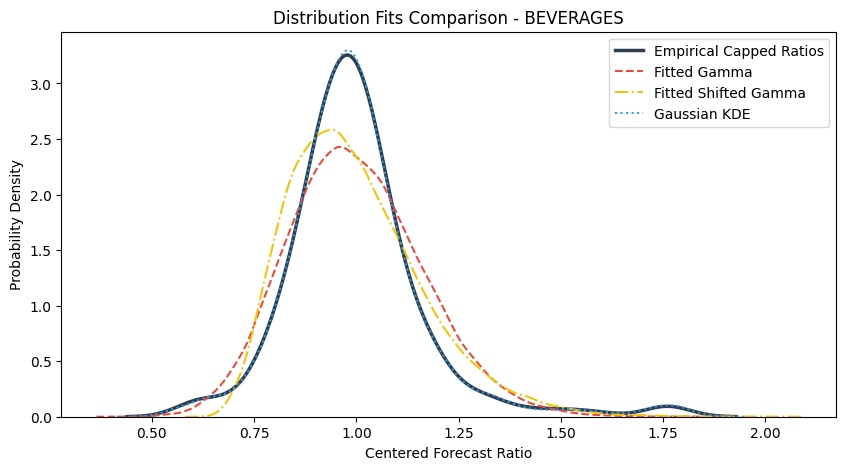


Goodness-of-Fit Summary - CLEANING
  Standard Gamma RMSE: 0.0189
  Shifted Gamma RMSE:  0.0080
  Gaussian KDE RMSE:   0.0070


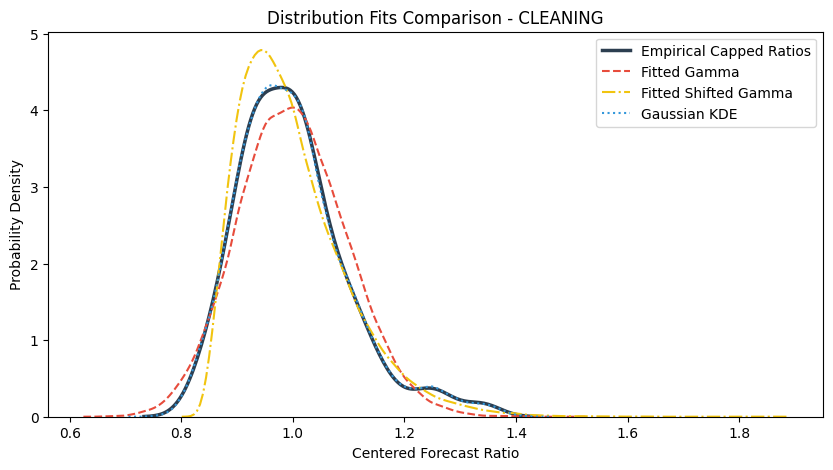

In [5]:
pcts = [90.0, 95.0, 97.5, 99.0]
fit_summary_rows = []

for family in config.selected_families:
    ratios_capped = results_uncertainty[family]['ratios_capped']
    
    # Fit Gamma distribution via moments
    k, theta = fit_gamma_moments(ratios_capped)
    gamma_samples = np.random.gamma(k, theta, size=50000)
    
    # Fit Shifted Gamma (shift c = P1 or minimum)
    c_shift = float(np.percentile(ratios_capped, 1.0))
    k_s, theta_s, _ = fit_shifted_gamma(ratios_capped, c_shift)
    shifted_gamma_samples = c_shift + np.random.gamma(k_s, theta_s, size=50000)
    
    # Draw samples from Gaussian KDE
    kde_samples = kde_sample(ratios_capped, size=50000, random_state=42)
    
    # Compare tails
    gamma_tail_err = calculate_tail_error(ratios_capped, gamma_samples, percentiles=pcts)
    shifted_gamma_tail_err = calculate_tail_error(ratios_capped, shifted_gamma_samples, percentiles=pcts)
    kde_tail_err = calculate_tail_error(ratios_capped, kde_samples, percentiles=pcts)
    
    # Compare general stats
    rmse_gamma = calculate_rmse(ratios_capped, gamma_samples)
    rmse_shifted = calculate_rmse(ratios_capped, shifted_gamma_samples)
    rmse_kde = calculate_rmse(ratios_capped, kde_samples)
    
    print(f"\nGoodness-of-Fit Summary - {family}")
    print(f"  Standard Gamma RMSE: {rmse_gamma:.4f}")
    print(f"  Shifted Gamma RMSE:  {rmse_shifted:.4f}")
    print(f"  Gaussian KDE RMSE:   {rmse_kde:.4f}")
    
    # Plot fits
    plt.figure(figsize=(10, 5))
    sns.kdeplot(ratios_capped, label='Empirical Capped Ratios', color='#2C3E50', linewidth=2.5)
    sns.kdeplot(gamma_samples, label='Fitted Gamma', color='#E74C3C', linestyle='--')
    sns.kdeplot(shifted_gamma_samples, label='Fitted Shifted Gamma', color='#F1C40F', linestyle='-.')
    sns.kdeplot(kde_samples, label='Gaussian KDE', color='#3498DB', linestyle=':')
    plt.title(f"Distribution Fits Comparison - {family}")
    plt.xlabel("Centered Forecast Ratio")
    plt.ylabel("Probability Density")
    plt.legend()
    plt.show()